# A: Import Libraries

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# B:  Data Preparation

## 1: Load Image and Validate

In [30]:
img = cv2.imread(r"cat.jpg")
if img is None:
    raise FileNotFoundError("Error: The image was not loaded successfully")

In [31]:
img

array([[[ 13,  13,  13],
        [ 13,  13,  13],
        [ 13,  13,  13],
        ...,
        [115, 115, 115],
        [109, 109, 109],
        [113, 113, 113]],

       [[ 13,  13,  13],
        [ 13,  13,  13],
        [ 13,  13,  13],
        ...,
        [120, 120, 120],
        [110, 110, 110],
        [108, 108, 108]],

       [[ 13,  13,  13],
        [ 13,  13,  13],
        [ 13,  13,  13],
        ...,
        [121, 121, 121],
        [112, 112, 112],
        [114, 114, 114]],

       ...,

       [[154, 154, 154],
        [169, 169, 169],
        [173, 173, 173],
        ...,
        [129, 129, 129],
        [119, 119, 119],
        [100, 100, 100]],

       [[166, 166, 166],
        [166, 166, 166],
        [161, 161, 161],
        ...,
        [127, 127, 127],
        [129, 129, 129],
        [119, 119, 119]],

       [[163, 163, 163],
        [171, 171, 171],
        [160, 160, 160],
        ...,
        [133, 133, 133],
        [119, 119, 119],
        [131, 131, 131]]

## 2: Check If Image Channels Are Identical

In [32]:
if np.array_equal(img[:,:,0], img[:,:,1]) and np.array_equal(img[:,:,1], img[:,:,2]):
    print("All channels are identical")
else:
    print("Channels are NOT identical")

All channels are identical


## 3: Extract a Single Channel


In [33]:
gray = img[:,:,0]
gray

array([[ 13,  13,  13, ..., 115, 109, 113],
       [ 13,  13,  13, ..., 120, 110, 108],
       [ 13,  13,  13, ..., 121, 112, 114],
       ...,
       [154, 169, 173, ..., 129, 119, 100],
       [166, 166, 161, ..., 127, 129, 119],
       [163, 171, 160, ..., 133, 119, 131]], shape=(256, 256), dtype=uint8)

## 4: Display Grayscale Image

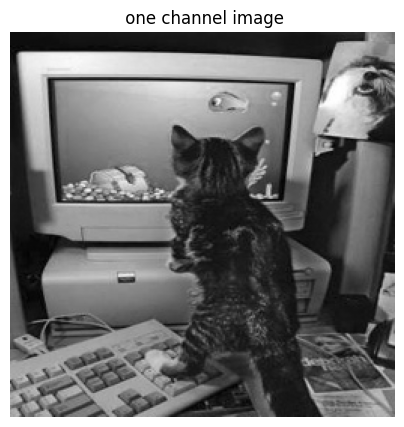

In [34]:
plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)

plt.title(" one channel image")
plt.axis('off')


plt.show()

# C: Histogram

## 1: Compute Histogram of Grayscale Image

### Using np.histogram

In [35]:
hist, bins = np.histogram(gray.ravel(), bins=256, range=(0, 256))

In [36]:
hist

array([   7,    9,    7,   20,   35,   47,   65,   91,  137,  160,  157,
        159,  175,  330,  275,  291,  333,  387,  531,  709,  916,  948,
       1144, 1220, 1183, 1153, 1010,  845,  771,  583,  529,  482,  495,
        454,  435,  428,  396,  399,  379,  393,  328,  360,  312,  337,
        327,  318,  328,  303,  278,  292,  241,  306,  265,  289,  246,
        240,  274,  279,  262,  266,  294,  289,  243,  309,  274,  282,
        275,  282,  327,  260,  256,  276,  275,  241,  273,  232,  236,
        242,  223,  235,  258,  268,  235,  225,  230,  248,  250,  224,
        213,  228,  242,  263,  278,  260,  247,  239,  291,  255,  264,
        233,  248,  228,  247,  237,  235,  224,  245,  231,  228,  234,
        238,  266,  249,  255,  275,  287,  278,  287,  280,  297,  275,
        291,  285,  277,  263,  275,  243,  309,  310,  286,  296,  294,
        309,  307,  282,  293,  306,  294,  275,  295,  304,  265,  285,
        284,  280,  258,  266,  301,  308,  299,  3

In [37]:
hist.shape

(256,)

In [38]:
bins

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

In [39]:
bins.shape
#why 257

(257,)

### Without Numpy

In [40]:
def histogram_gray(pic, bins=256):
    # Create an array for counting occurrences
    hist = [0] * bins
    bin_size = 256 // bins  # For bins=256, this becomes 1

    # Flatten the image and count pixel values
    for row in pic:
        for value in row:
            # Ensure the value is within 0–255
            v = int(value)
            if 0 <= v < 256:
                hist[v // bin_size] += 1

    # Create bin edges similar to np.histogram
    bin_edges = [i * bin_size for i in range(bins + 1)]

    return hist, bin_edges

In [41]:
hist_w , bin_w = histogram_gray(gray)
print(hist_w)

[7, 9, 7, 20, 35, 47, 65, 91, 137, 160, 157, 159, 175, 330, 275, 291, 333, 387, 531, 709, 916, 948, 1144, 1220, 1183, 1153, 1010, 845, 771, 583, 529, 482, 495, 454, 435, 428, 396, 399, 379, 393, 328, 360, 312, 337, 327, 318, 328, 303, 278, 292, 241, 306, 265, 289, 246, 240, 274, 279, 262, 266, 294, 289, 243, 309, 274, 282, 275, 282, 327, 260, 256, 276, 275, 241, 273, 232, 236, 242, 223, 235, 258, 268, 235, 225, 230, 248, 250, 224, 213, 228, 242, 263, 278, 260, 247, 239, 291, 255, 264, 233, 248, 228, 247, 237, 235, 224, 245, 231, 228, 234, 238, 266, 249, 255, 275, 287, 278, 287, 280, 297, 275, 291, 285, 277, 263, 275, 243, 309, 310, 286, 296, 294, 309, 307, 282, 293, 306, 294, 275, 295, 304, 265, 285, 284, 280, 258, 266, 301, 308, 299, 334, 333, 385, 402, 371, 398, 403, 447, 447, 376, 356, 380, 346, 375, 368, 388, 367, 389, 318, 301, 283, 269, 299, 238, 238, 244, 214, 237, 247, 207, 206, 213, 184, 220, 183, 238, 217, 190, 194, 208, 201, 218, 163, 195, 165, 171, 152, 139, 163, 154, 149, 

In [42]:
print(bin_w)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

## 2: Plot and Save Original Histogram

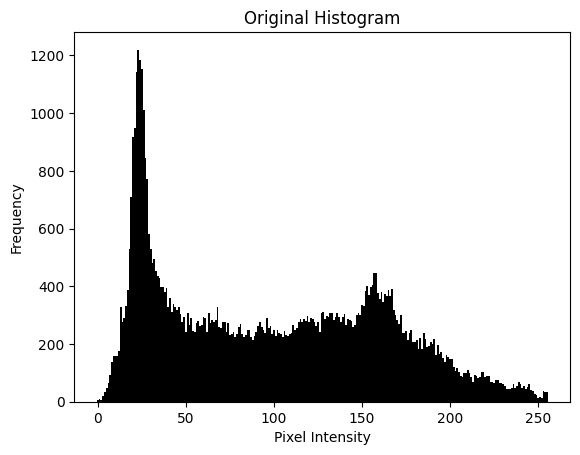

In [43]:
plt.bar(np.arange(256), hist, width=1.0, color='black')

plt.title('Original Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')

plt.savefig('oroginal_histogram.jpg', dpi=300)

plt.show()

## 3: Normalize Histogram

In [44]:
hist_norm = hist / hist.sum()

In [45]:
hist_norm
# hist_norm is PDF

array([0.00010681, 0.00013733, 0.00010681, 0.00030518, 0.00053406,
       0.00071716, 0.00099182, 0.00138855, 0.00209045, 0.00244141,
       0.00239563, 0.00242615, 0.00267029, 0.0050354 , 0.00419617,
       0.00444031, 0.00508118, 0.00590515, 0.00810242, 0.01081848,
       0.01397705, 0.01446533, 0.01745605, 0.01861572, 0.01805115,
       0.01759338, 0.01541138, 0.01289368, 0.01176453, 0.00889587,
       0.0080719 , 0.00735474, 0.0075531 , 0.00692749, 0.00663757,
       0.00653076, 0.00604248, 0.00608826, 0.00578308, 0.0059967 ,
       0.00500488, 0.00549316, 0.00476074, 0.00514221, 0.00498962,
       0.00485229, 0.00500488, 0.00462341, 0.00424194, 0.00445557,
       0.00367737, 0.00466919, 0.00404358, 0.00440979, 0.00375366,
       0.00366211, 0.00418091, 0.0042572 , 0.0039978 , 0.00405884,
       0.00448608, 0.00440979, 0.00370789, 0.00471497, 0.00418091,
       0.00430298, 0.00419617, 0.00430298, 0.00498962, 0.00396729,
       0.00390625, 0.00421143, 0.00419617, 0.00367737, 0.00416

In [46]:
hist_norm.sum()  # → 1.0

np.float64(1.0)

## 4: Plot and Save Normalized Histogram

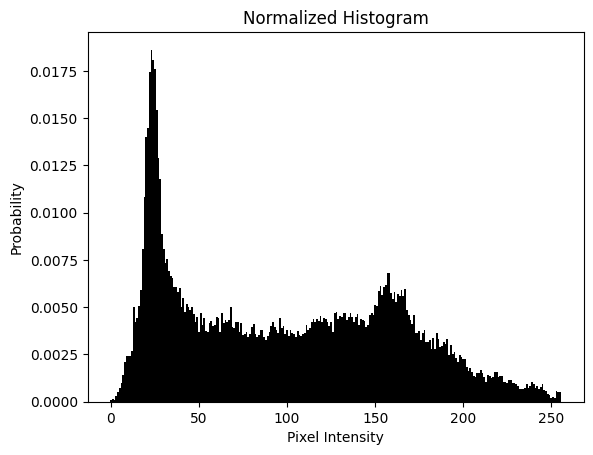

In [47]:
plt.bar(np.arange(256), hist_norm, width=1.0, color='black')

plt.title('Normalized Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.savefig('normalized_histogram.jpg', dpi=300)
plt.show()

# D: Histogram Equalization

## 1: Compute CDF (Cumulative Distribution Function)

In [48]:
cdf = np.cumsum(hist_norm)

In [49]:
cdf

array([1.06811523e-04, 2.44140625e-04, 3.50952148e-04, 6.56127930e-04,
       1.19018555e-03, 1.90734863e-03, 2.89916992e-03, 4.28771973e-03,
       6.37817383e-03, 8.81958008e-03, 1.12152100e-02, 1.36413574e-02,
       1.63116455e-02, 2.13470459e-02, 2.55432129e-02, 2.99835205e-02,
       3.50646973e-02, 4.09698486e-02, 4.90722656e-02, 5.98907471e-02,
       7.38677979e-02, 8.83331299e-02, 1.05789185e-01, 1.24404907e-01,
       1.42456055e-01, 1.60049438e-01, 1.75460815e-01, 1.88354492e-01,
       2.00119019e-01, 2.09014893e-01, 2.17086792e-01, 2.24441528e-01,
       2.31994629e-01, 2.38922119e-01, 2.45559692e-01, 2.52090454e-01,
       2.58132935e-01, 2.64221191e-01, 2.70004272e-01, 2.76000977e-01,
       2.81005859e-01, 2.86499023e-01, 2.91259766e-01, 2.96401978e-01,
       3.01391602e-01, 3.06243896e-01, 3.11248779e-01, 3.15872192e-01,
       3.20114136e-01, 3.24569702e-01, 3.28247070e-01, 3.32916260e-01,
       3.36959839e-01, 3.41369629e-01, 3.45123291e-01, 3.48785400e-01,
      

## 2: Plot and Save Normalized Histogram

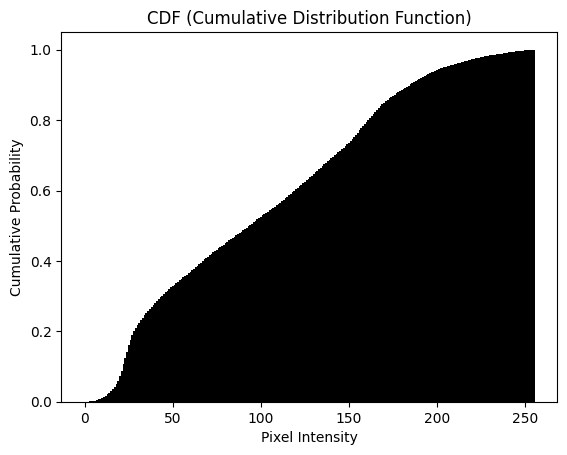

In [50]:
plt.bar(np.arange(256), cdf, width=1.0, color='black')

plt.title('CDF (Cumulative Distribution Function)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.savefig('CDF.jpg', dpi=300)
plt.show()


## 3: Compute Scaled CDF (Lookup Table for Histogram Equalization)

In [51]:
L = 256
cdf_scaled = np.floor((L - 1) * cdf).astype(np.uint8)
cdf_scaled

array([  0,   0,   0,   0,   0,   0,   0,   1,   1,   2,   2,   3,   4,
         5,   6,   7,   8,  10,  12,  15,  18,  22,  26,  31,  36,  40,
        44,  48,  51,  53,  55,  57,  59,  60,  62,  64,  65,  67,  68,
        70,  71,  73,  74,  75,  76,  78,  79,  80,  81,  82,  83,  84,
        85,  87,  88,  88,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100, 101, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124,
       125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 134, 135, 136,
       137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
       150, 151, 152, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163,
       164, 166, 167, 168, 169, 170, 171, 173, 174, 175, 176, 177, 178,
       179, 180, 181, 182, 184, 185, 186, 187, 188, 190, 192, 193, 195,
       196, 198, 200, 201, 202, 204, 205, 207, 208, 210, 211, 213, 214,
       215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 22

In [52]:
cdf_scaled.shape

(256,)

## 4: Apply Equalization to Grayscale Image(Lookup Table Mapping)

In [53]:
equalized = cdf_scaled[gray]
equalized

array([[  5,   5,   5, ..., 148, 142, 146],
       [  5,   5,   5, ..., 153, 143, 141],
       [  5,   5,   5, ..., 155, 145, 147],
       ...,
       [193, 215, 219, ..., 163, 152, 134],
       [211, 211, 204, ..., 161, 163, 152],
       [207, 217, 202, ..., 168, 152, 166]], shape=(256, 256), dtype=uint8)

## 5: Display and Save Equalized Image

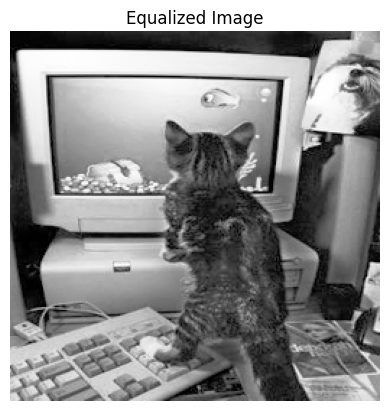

True

In [54]:
plt.imshow(equalized, cmap='gray', vmin=0, vmax=255)
plt.title('Equalized Image')
plt.axis('off')
plt.show()

cv2.imwrite('equalized_img.png', equalized)

## 6: Compute Histogram of Equalized Image

In [55]:
hist_eq, _ = np.histogram(equalized.ravel(), bins=256, range=(0,256))
hist_eq

array([ 190,  228,  317,  159,  175,  330,  275,  291,  333,    0,  387,
          0,  531,    0,    0,  709,    0,    0,  916,    0,    0,    0,
        948,    0,    0,    0, 1144,    0,    0,    0,    0, 1220,    0,
          0,    0,    0, 1183,    0,    0,    0, 1153,    0,    0,    0,
       1010,    0,    0,    0,  845,    0,    0,  771,    0,  583,    0,
        529,    0,  482,    0,  495,  454,    0,  435,    0,  428,  396,
          0,  399,  379,    0,  393,  328,    0,  360,  312,  337,  327,
          0,  318,  328,  303,  278,  292,  241,  306,  265,    0,  289,
        486,    0,  274,  279,  262,  266,  294,  289,  243,  309,  274,
        282,  275,  282,    0,  327,  260,  256,  276,  275,  241,  273,
        232,  236,  465,  235,  258,  268,  235,  225,  230,  248,  250,
        224,  213,  228,  242,  263,  278,  260,  247,  239,  291,  255,
        264,  233,  476,  247,  237,  235,  224,  245,  231,  228,  234,
        238,  266,  249,  255,  275,  287,  278,  2

## 7: Plot and Save Histogram of Equalized Image

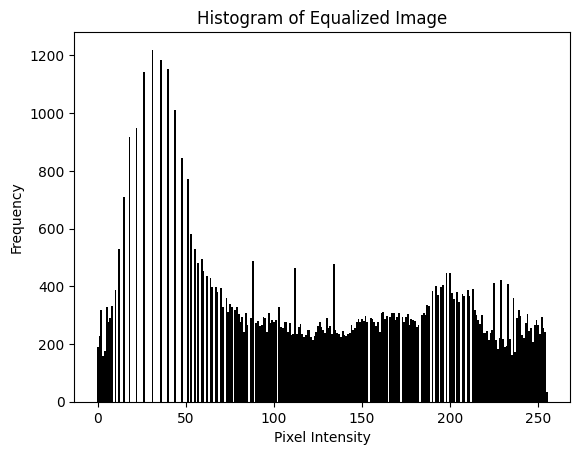

In [56]:
plt.bar(range(256), hist_eq, width=1.0, color='black')
plt.title('Histogram of Equalized Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.savefig('equalized_histogram.jpg', dpi=300)
plt.show()
